In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.diagnostic import (
    het_breuschpagan,
    acorr_ljungbox
)
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.float_format", "{:.6f}".format)
pd.set_option("display.max_columns", 15)

# Load processed data
ff5 = pd.read_csv(
    "../data/processed/ff5_factors.csv",
    index_col=0, parse_dates=True
)
excess = pd.read_csv(
    "../data/processed/excess_returns.csv",
    index_col=0, parse_dates=True
)
returns = pd.read_csv(
    "../data/processed/stock_returns.csv",
    index_col=0, parse_dates=True
)

tickers = ["AAPL", "BRK-B", "TSLA", "JNJ", "SPY"]
factors = ["Mkt_RF", "SMB", "HML", "RMW", "CMA"]

# Confirm alignment
print("=" * 55)
print("   DATA LOADED SUCCESSFULLY")
print("=" * 55)
print(f"  FF5 factors:    {ff5.shape}")
print(f"  Excess returns: {excess.shape}")
print(f"  Stock returns:  {returns.shape}")
print(f"  Date range:     {ff5.index[0].date()} "
      f"to {ff5.index[-1].date()}")
print(f"  Tickers:        {tickers}")
print(f"  Factors:        {factors}")
print("=" * 55)

# Verify no NaN in inputs
print(f"\nMissing values check:")
print(f"  FF5: {ff5.isnull().sum().sum()}")
print(f"  Excess: {excess.isnull().sum().sum()}")

   DATA LOADED SUCCESSFULLY
  FF5 factors:    (3650, 6)
  Excess returns: (3650, 5)
  Stock returns:  (3650, 5)
  Date range:     2010-06-30 to 2024-12-30
  Tickers:        ['AAPL', 'BRK-B', 'TSLA', 'JNJ', 'SPY']
  Factors:        ['Mkt_RF', 'SMB', 'HML', 'RMW', 'CMA']

Missing values check:
  FF5: 0
  Excess: 0


In [2]:
def run_ff5_regression(
        ticker: str,
        excess_df: pd.DataFrame,
        ff5_df: pd.DataFrame,
        factors: list) -> dict:
    """
    Run Fama-French 5-Factor OLS regression
    for a single stock with full diagnostics.

    Uses HAC (Newey-West) standard errors —
    essential for financial time series which
    exhibit autocorrelation and heteroskedasticity.

    Parameters:
        ticker:     stock ticker string
        excess_df:  excess returns DataFrame
        ff5_df:     FF5 factor DataFrame
        factors:    list of factor column names

    Returns:
        dict of model, params, stats, diagnostics
    """
    # Align data
    y = excess_df[ticker].dropna()
    X = sm.add_constant(ff5_df[factors])
    X.columns = ["Alpha"] + factors
    X = X.loc[y.index].dropna()
    y = y.loc[X.index]

    # ----------------------------------------
    # OLS with HAC standard errors
    # maxlags=5 is standard for daily returns
    # Newey-West correction for:
    # 1. Autocorrelation in residuals
    # 2. Heteroskedasticity (ARCH effects)
    # ----------------------------------------
    model = sm.OLS(y, X).fit(
        cov_type="HAC",
        cov_kwds={"maxlags": 5}
    )

    # ----------------------------------------
    # DIAGNOSTIC TESTS
    # ----------------------------------------

    # 1. Breusch-Pagan test for heteroskedasticity
    # H0: residuals are homoskedastic
    bp_stat, bp_pval, _, _ = het_breuschpagan(
        model.resid, model.model.exog)

    # 2. Ljung-Box test for autocorrelation
    # H0: no autocorrelation in residuals
    lb_result = acorr_ljungbox(
        model.resid, lags=10, return_df=True)
    lb_pval = float(lb_result["lb_pvalue"].iloc[-1])

    # 3. Jarque-Bera normality test
    # H0: residuals are normally distributed
    jb_stat, jb_pval = stats.jarque_bera(
        model.resid)[:2]

    # 4. Annualised alpha and information ratio
    alpha_daily  = model.params["Alpha"]
    alpha_ann    = alpha_daily * 252
    resid_vol    = model.resid.std() * np.sqrt(252)
    info_ratio   = alpha_ann / resid_vol

    # 5. Treynor ratio
    market_beta  = model.params["Mkt_RF"]
    ann_ret      = returns[ticker].mean() * 252
    rf_ann       = ff5_df["RF"].mean() * 252
    treynor      = ((ann_ret - rf_ann) /
                    market_beta if market_beta != 0
                    else np.nan)

    return {
        "model":        model,
        "ticker":       ticker,
        "n_obs":        len(y),
        "params":       model.params,
        "tvalues":      model.tvalues,
        "pvalues":      model.pvalues,
        "conf_int":     model.conf_int(),
        "rsquared":     model.rsquared,
        "rsquared_adj": model.rsquared_adj,
        "alpha_daily":  alpha_daily,
        "alpha_ann":    alpha_ann,
        "info_ratio":   info_ratio,
        "treynor":      treynor,
        "resid_vol":    resid_vol,
        "aic":          model.aic,
        "bic":          model.bic,
        # Diagnostics
        "bp_stat":      bp_stat,
        "bp_pval":      bp_pval,
        "lb_pval":      lb_pval,
        "jb_stat":      jb_stat,
        "jb_pval":      jb_pval,
        "resid":        model.resid,
        "fitted":       model.fittedvalues,
    }

print("OLS regression function defined")
print("Features:")
print("  HAC (Newey-West) standard errors")
print("  Breusch-Pagan heteroskedasticity test")
print("  Ljung-Box autocorrelation test")
print("  Jarque-Bera normality test")
print("  Annualised alpha + information ratio")
print("  Treynor ratio per stock")

OLS regression function defined
Features:
  HAC (Newey-West) standard errors
  Breusch-Pagan heteroskedasticity test
  Ljung-Box autocorrelation test
  Jarque-Bera normality test
  Annualised alpha + information ratio
  Treynor ratio per stock


In [3]:
# ============================================
# RUN FF5 REGRESSION FOR ALL TICKERS
# ============================================
results = {}

print("Running Fama-French 5-Factor OLS...")
print("=" * 65)

for ticker in tickers:
    if ticker not in excess.columns:
        print(f"  {ticker}: not found in data — skipping")
        continue

    res = run_ff5_regression(
        ticker, excess, ff5, factors)
    results[ticker] = res

    # Significance stars
    alpha_p = res["pvalues"]["Alpha"]
    sig = ("***" if alpha_p < 0.01 else
           "**"  if alpha_p < 0.05 else
           "*"   if alpha_p < 0.10 else
           "ns")

    print(f"\n  {ticker} {sig}")
    print(f"  Obs:         {res['n_obs']:,}")
    print(f"  Alpha (ann): {res['alpha_ann']:.4f} "
          f"({res['alpha_ann']:.2%}) "
          f"t={res['tvalues']['Alpha']:.2f} "
          f"p={res['pvalues']['Alpha']:.4f}")
    print(f"  Market beta: {res['params']['Mkt_RF']:.4f} "
          f"t={res['tvalues']['Mkt_RF']:.2f}")
    print(f"  SMB:         {res['params']['SMB']:.4f}")
    print(f"  HML:         {res['params']['HML']:.4f}")
    print(f"  RMW:         {res['params']['RMW']:.4f}")
    print(f"  CMA:         {res['params']['CMA']:.4f}")
    print(f"  R-squared:   {res['rsquared']:.4f}")
    print(f"  Adj R-sq:    {res['rsquared_adj']:.4f}")
    print(f"  Info ratio:  {res['info_ratio']:.4f}")
    print(f"  Treynor:     {res['treynor']:.4f}")

print("\n" + "=" * 65)
print("*** p<0.01  ** p<0.05  * p<0.10  ns = not significant")

Running Fama-French 5-Factor OLS...

  AAPL ns
  Obs:         3,650
  Alpha (ann): 0.0747 (7.47%) t=1.48 p=0.1396
  Market beta: 1.1484 t=52.02
  SMB:         -0.1408
  HML:         -0.4872
  RMW:         0.5879
  CMA:         -0.0510
  R-squared:   0.5283
  Adj R-sq:    0.5277
  Info ratio:  0.3925
  Treynor:     0.2330

  BRK-B ns
  Obs:         3,650
  Alpha (ann): 0.0119 (1.19%) t=0.45 p=0.6548
  Market beta: 0.8890 t=50.65
  SMB:         -0.2589
  HML:         0.5476
  RMW:         -0.1276
  CMA:         0.0031
  R-squared:   0.7383
  Adj R-sq:    0.7380
  Info ratio:  0.1218
  Treynor:     0.1418

  TSLA ***
  Obs:         3,650
  Alpha (ann): 0.3743 (37.43%) t=2.89 p=0.0039
  Market beta: 1.2449 t=18.22
  SMB:         0.3973
  HML:         -0.4901
  RMW:         -0.6308
  CMA:         -0.9624
  R-squared:   0.2579
  Adj R-sq:    0.2569
  Info ratio:  0.7572
  Treynor:     0.4310

  JNJ ns
  Obs:         3,650
  Alpha (ann): -0.0060 (-0.60%) t=-0.17 p=0.8627
  Market beta: 0.6255

In [4]:
# ============================================
# COMPREHENSIVE SUMMARY TABLE
# ============================================
rows = []
for ticker, res in results.items():
    alpha_p = res["pvalues"]["Alpha"]
    sig = ("***" if alpha_p < 0.01 else
           "**"  if alpha_p < 0.05 else
           "*"   if alpha_p < 0.10 else "ns")

    rows.append({
        "Ticker":        ticker,
        "Alpha_ann%":    round(res["alpha_ann"]*100, 3),
        "Alpha_tstat":   round(res["tvalues"]["Alpha"], 3),
        "Alpha_sig":     sig,
        "Mkt_RF":        round(res["params"]["Mkt_RF"], 4),
        "SMB":           round(res["params"]["SMB"], 4),
        "HML":           round(res["params"]["HML"], 4),
        "RMW":           round(res["params"]["RMW"], 4),
        "CMA":           round(res["params"]["CMA"], 4),
        "R2":            round(res["rsquared"], 4),
        "Adj_R2":        round(res["rsquared_adj"], 4),
        "Info_Ratio":    round(res["info_ratio"], 4),
    })

summary = pd.DataFrame(rows).set_index("Ticker")

print("=" * 85)
print("   FAMA-FRENCH 5-FACTOR LOADINGS — FULL SUMMARY")
print("=" * 85)
print(summary.to_string())
print("=" * 85)

# Save
summary.to_csv(
    "../data/processed/ols_summary.csv")
print("\nSaved to data/processed/ols_summary.csv")

   FAMA-FRENCH 5-FACTOR LOADINGS — FULL SUMMARY
        Alpha_ann%  Alpha_tstat Alpha_sig   Mkt_RF       SMB       HML       RMW       CMA       R2   Adj_R2  Info_Ratio
Ticker                                                                                                                  
AAPL      7.475000     1.477000        ns 1.148400 -0.140800 -0.487200  0.587900 -0.051000 0.528300 0.527700    0.392500
BRK-B     1.190000     0.447000        ns 0.889000 -0.258900  0.547600 -0.127600  0.003100 0.738300 0.738000    0.121800
TSLA     37.426000     2.887000       *** 1.244900  0.397300 -0.490100 -0.630800 -0.962400 0.257900 0.256900    0.757200
JNJ      -0.599000    -0.173000        ns 0.625500 -0.254500 -0.042000  0.201200  0.457900 0.363600 0.362800   -0.044700
SPY      -0.140000    -0.596000        ns 0.983500 -0.108300  0.022700  0.055800  0.029700 0.995500 0.995500   -0.123600

Saved to data/processed/ols_summary.csv


In [5]:
# ============================================
# REGRESSION DIAGNOSTIC TESTS
# ============================================
diag_rows = []
for ticker, res in results.items():
    diag_rows.append({
        "Ticker":       ticker,
        "BP_stat":      round(res["bp_stat"], 3),
        "BP_pval":      round(res["bp_pval"], 4),
        "Heterosk":     ("Yes" if res["bp_pval"] < 0.05
                         else "No"),
        "LB_pval":      round(res["lb_pval"], 4),
        "Autocorr":     ("Yes" if res["lb_pval"] < 0.05
                         else "No"),
        "JB_stat":      round(res["jb_stat"], 1),
        "JB_pval":      round(res["jb_pval"], 4),
        "Normal_res":   ("Yes" if res["jb_pval"] > 0.05
                         else "No"),
        "AIC":          round(res["aic"], 1),
        "BIC":          round(res["bic"], 1),
    })

diag_df = pd.DataFrame(diag_rows).set_index("Ticker")

print("=" * 75)
print("   REGRESSION DIAGNOSTIC TESTS")
print("=" * 75)
print(diag_df.to_string())
print("=" * 75)
print(f"\nInterpretation:")
print(f"  BP test:  Heterosk=Yes → heteroskedastic residuals")
print(f"            HAC errors correct for this automatically")
print(f"  LB test:  Autocorr=Yes → autocorrelated residuals")
print(f"            HAC errors correct for this automatically")
print(f"  JB test:  Normal=No → fat-tailed residuals")
print(f"            Expected for financial returns (kurtosis > 3)")
print(f"\nConclusion: HAC standard errors are the correct choice")
print(f"for all tickers regardless of diagnostic outcomes")

   REGRESSION DIAGNOSTIC TESTS
         BP_stat  BP_pval Heterosk  LB_pval Autocorr      JB_stat  JB_pval Normal_res           AIC           BIC
Ticker                                                                                                           
AAPL    6.135000 0.293300       No 0.413400       No  9096.300000 0.000000         No -21920.100000 -21882.800000
BRK-B  38.794000 0.000000      Yes 0.027500      Yes  5588.800000 0.000000         No -26792.100000 -26754.800000
TSLA    5.319000 0.378200       No 0.291400       No  7064.100000 0.000000         No -14957.100000 -14919.900000
JNJ    11.390000 0.044200      Yes 0.297000       No 11445.000000 0.000000         No -24483.700000 -24446.500000
SPY    24.126000 0.000200      Yes 0.000000      Yes 10461.300000 0.000000         No -42517.400000 -42480.200000

Interpretation:
  BP test:  Heterosk=Yes → heteroskedastic residuals
            HAC errors correct for this automatically
  LB test:  Autocorr=Yes → autocorrelated resid

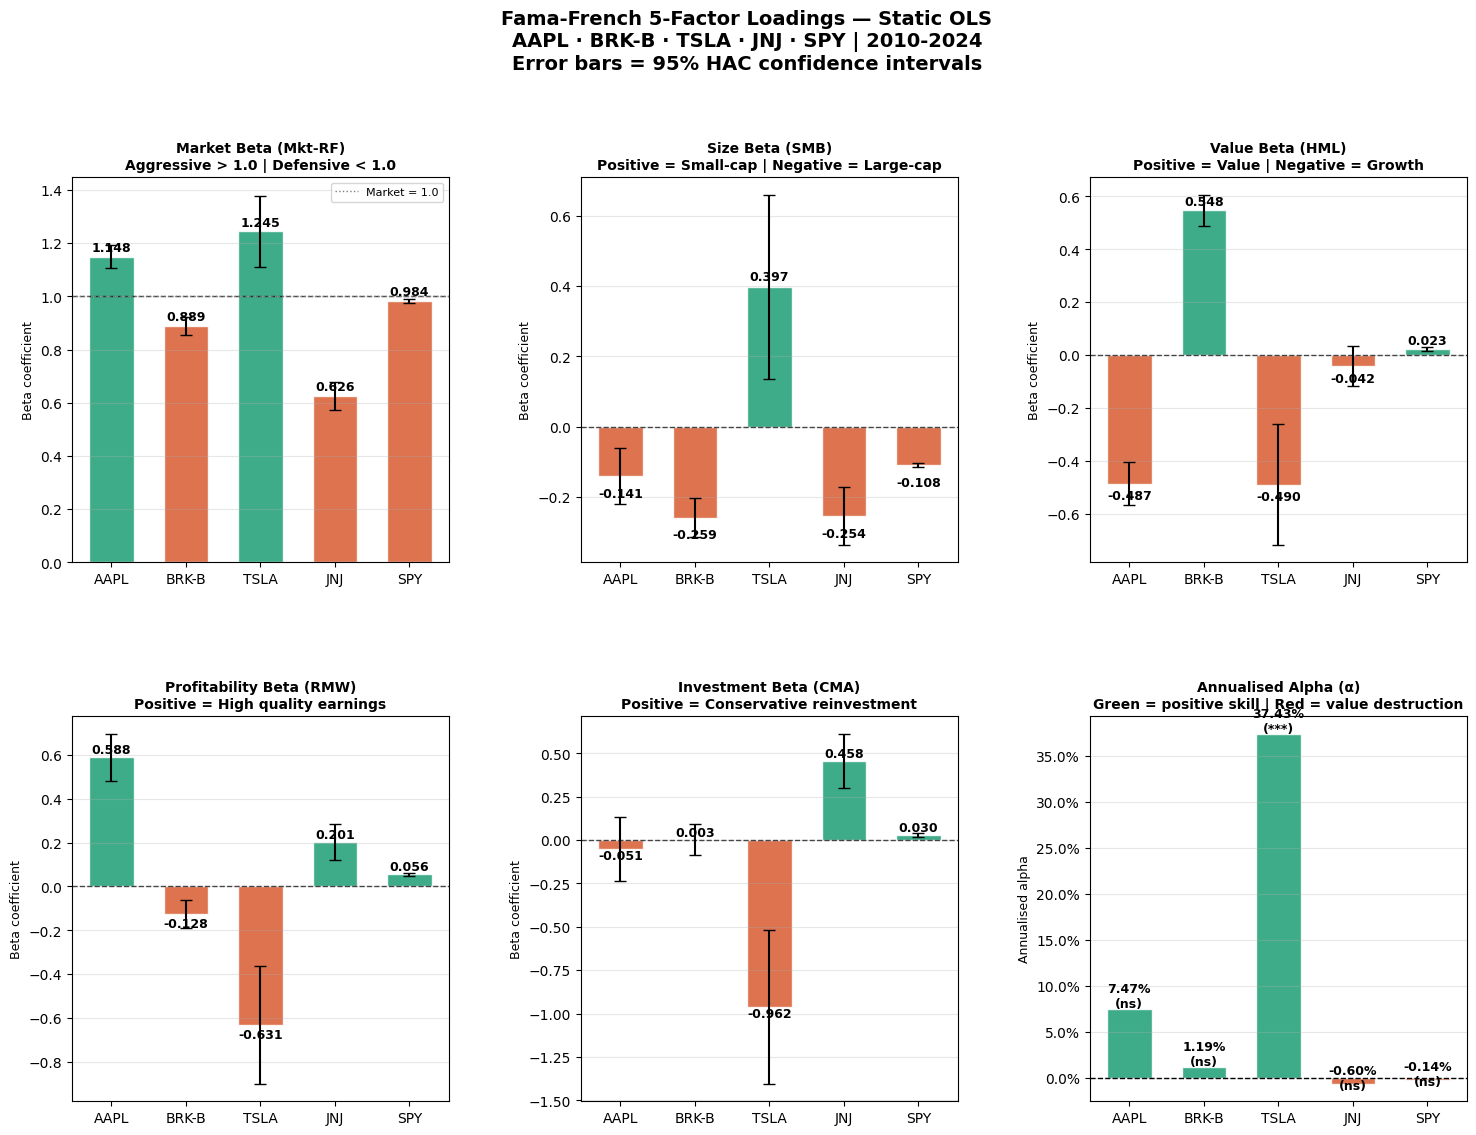

Factor loadings chart saved


In [6]:
# ============================================
# FACTOR LOADINGS CHART — 6 panels
# ============================================
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig,
                        hspace=0.4, wspace=0.35)

plot_items = [
    ("Mkt_RF", "Market Beta (Mkt-RF)",
     "Aggressive > 1.0 | Defensive < 1.0",
     "#378ADD", 1.0),
    ("SMB",    "Size Beta (SMB)",
     "Positive = Small-cap | Negative = Large-cap",
     "#1D9E75", 0.0),
    ("HML",    "Value Beta (HML)",
     "Positive = Value | Negative = Growth",
     "#D85A30", 0.0),
    ("RMW",    "Profitability Beta (RMW)",
     "Positive = High quality earnings",
     "#7F77DD", 0.0),
    ("CMA",    "Investment Beta (CMA)",
     "Positive = Conservative reinvestment",
     "#BA7517", 0.0),
]

for idx, (factor, title, subtitle,
          color, ref_line) in enumerate(plot_items):
    ax = fig.add_subplot(gs[idx // 3, idx % 3])

    loadings   = [results[t]["params"][factor]
                  for t in tickers if t in results]
    ci_lower   = [results[t]["conf_int"].loc[factor, 0]
                  for t in tickers if t in results]
    ci_upper   = [results[t]["conf_int"].loc[factor, 1]
                  for t in tickers if t in results]
    tick_labels= [t for t in tickers if t in results]

    bar_colors = [
        "#1D9E75" if v >= ref_line else "#D85A30"
        for v in loadings
    ]

    x_pos = np.arange(len(tick_labels))
    bars  = ax.bar(
        x_pos, loadings,
        color=bar_colors,
        edgecolor="white",
        alpha=0.85, width=0.6
    )

    # Confidence interval error bars
    errors_low  = [l - ci for l, ci
                   in zip(loadings, ci_lower)]
    errors_high = [ci - l for l, ci
                   in zip(loadings, ci_upper)]
    ax.errorbar(
        x_pos, loadings,
        yerr=[errors_low, errors_high],
        fmt="none",
        color="black",
        capsize=4,
        linewidth=1.5
    )

    ax.axhline(
        ref_line, color="black",
        linewidth=1, linestyle="--",
        alpha=0.7
    )
    if factor == "Mkt_RF":
        ax.axhline(
            1.0, color="grey",
            linewidth=1, linestyle=":",
            label="Market = 1.0"
        )
        ax.legend(fontsize=8)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(tick_labels, fontsize=10)
    ax.set_title(
        f"{title}\n{subtitle}",
        fontweight="bold", fontsize=10
    )
    ax.set_ylabel("Beta coefficient", fontsize=9)
    ax.grid(alpha=0.3, axis="y")

    for bar, val in zip(bars, loadings):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() +
            (0.02 if val >= 0 else -0.06),
            f"{val:.3f}",
            ha="center", fontsize=9,
            fontweight="bold"
        )

# Alpha panel — bottom right
ax6 = fig.add_subplot(gs[1, 2])
alphas = [results[t]["alpha_ann"]
          for t in tickers if t in results]
pvals  = [results[t]["pvalues"]["Alpha"]
          for t in tickers if t in results]

alpha_colors = [
    "#1D9E75" if a > 0 else "#D85A30"
    for a in alphas
]
bars6 = ax6.bar(
    np.arange(len(tick_labels)),
    alphas,
    color=alpha_colors,
    edgecolor="white",
    alpha=0.85, width=0.6
)
ax6.axhline(
    0, color="black",
    linewidth=1, linestyle="--")
ax6.set_xticks(np.arange(len(tick_labels)))
ax6.set_xticklabels(tick_labels, fontsize=10)
ax6.set_title(
    "Annualised Alpha (α)\n"
    "Green = positive skill | Red = value destruction",
    fontweight="bold", fontsize=10
)
ax6.set_ylabel("Annualised alpha", fontsize=9)
ax6.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.1%}"))
ax6.grid(alpha=0.3, axis="y")

for bar, val, pval in zip(bars6, alphas, pvals):
    sig = ("***" if pval < 0.01 else
           "**"  if pval < 0.05 else
           "*"   if pval < 0.10 else "ns")
    ax6.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() +
        (0.002 if val >= 0 else -0.006),
        f"{val:.2%}\n({sig})",
        ha="center", fontsize=9,
        fontweight="bold"
    )

plt.suptitle(
    "Fama-French 5-Factor Loadings — Static OLS\n"
    "AAPL · BRK-B · TSLA · JNJ · SPY | 2010-2024\n"
    "Error bars = 95% HAC confidence intervals",
    fontsize=14, fontweight="bold", y=1.02
)
plt.savefig(
    "../reports/figures/ff5_factor_loadings.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Factor loadings chart saved")

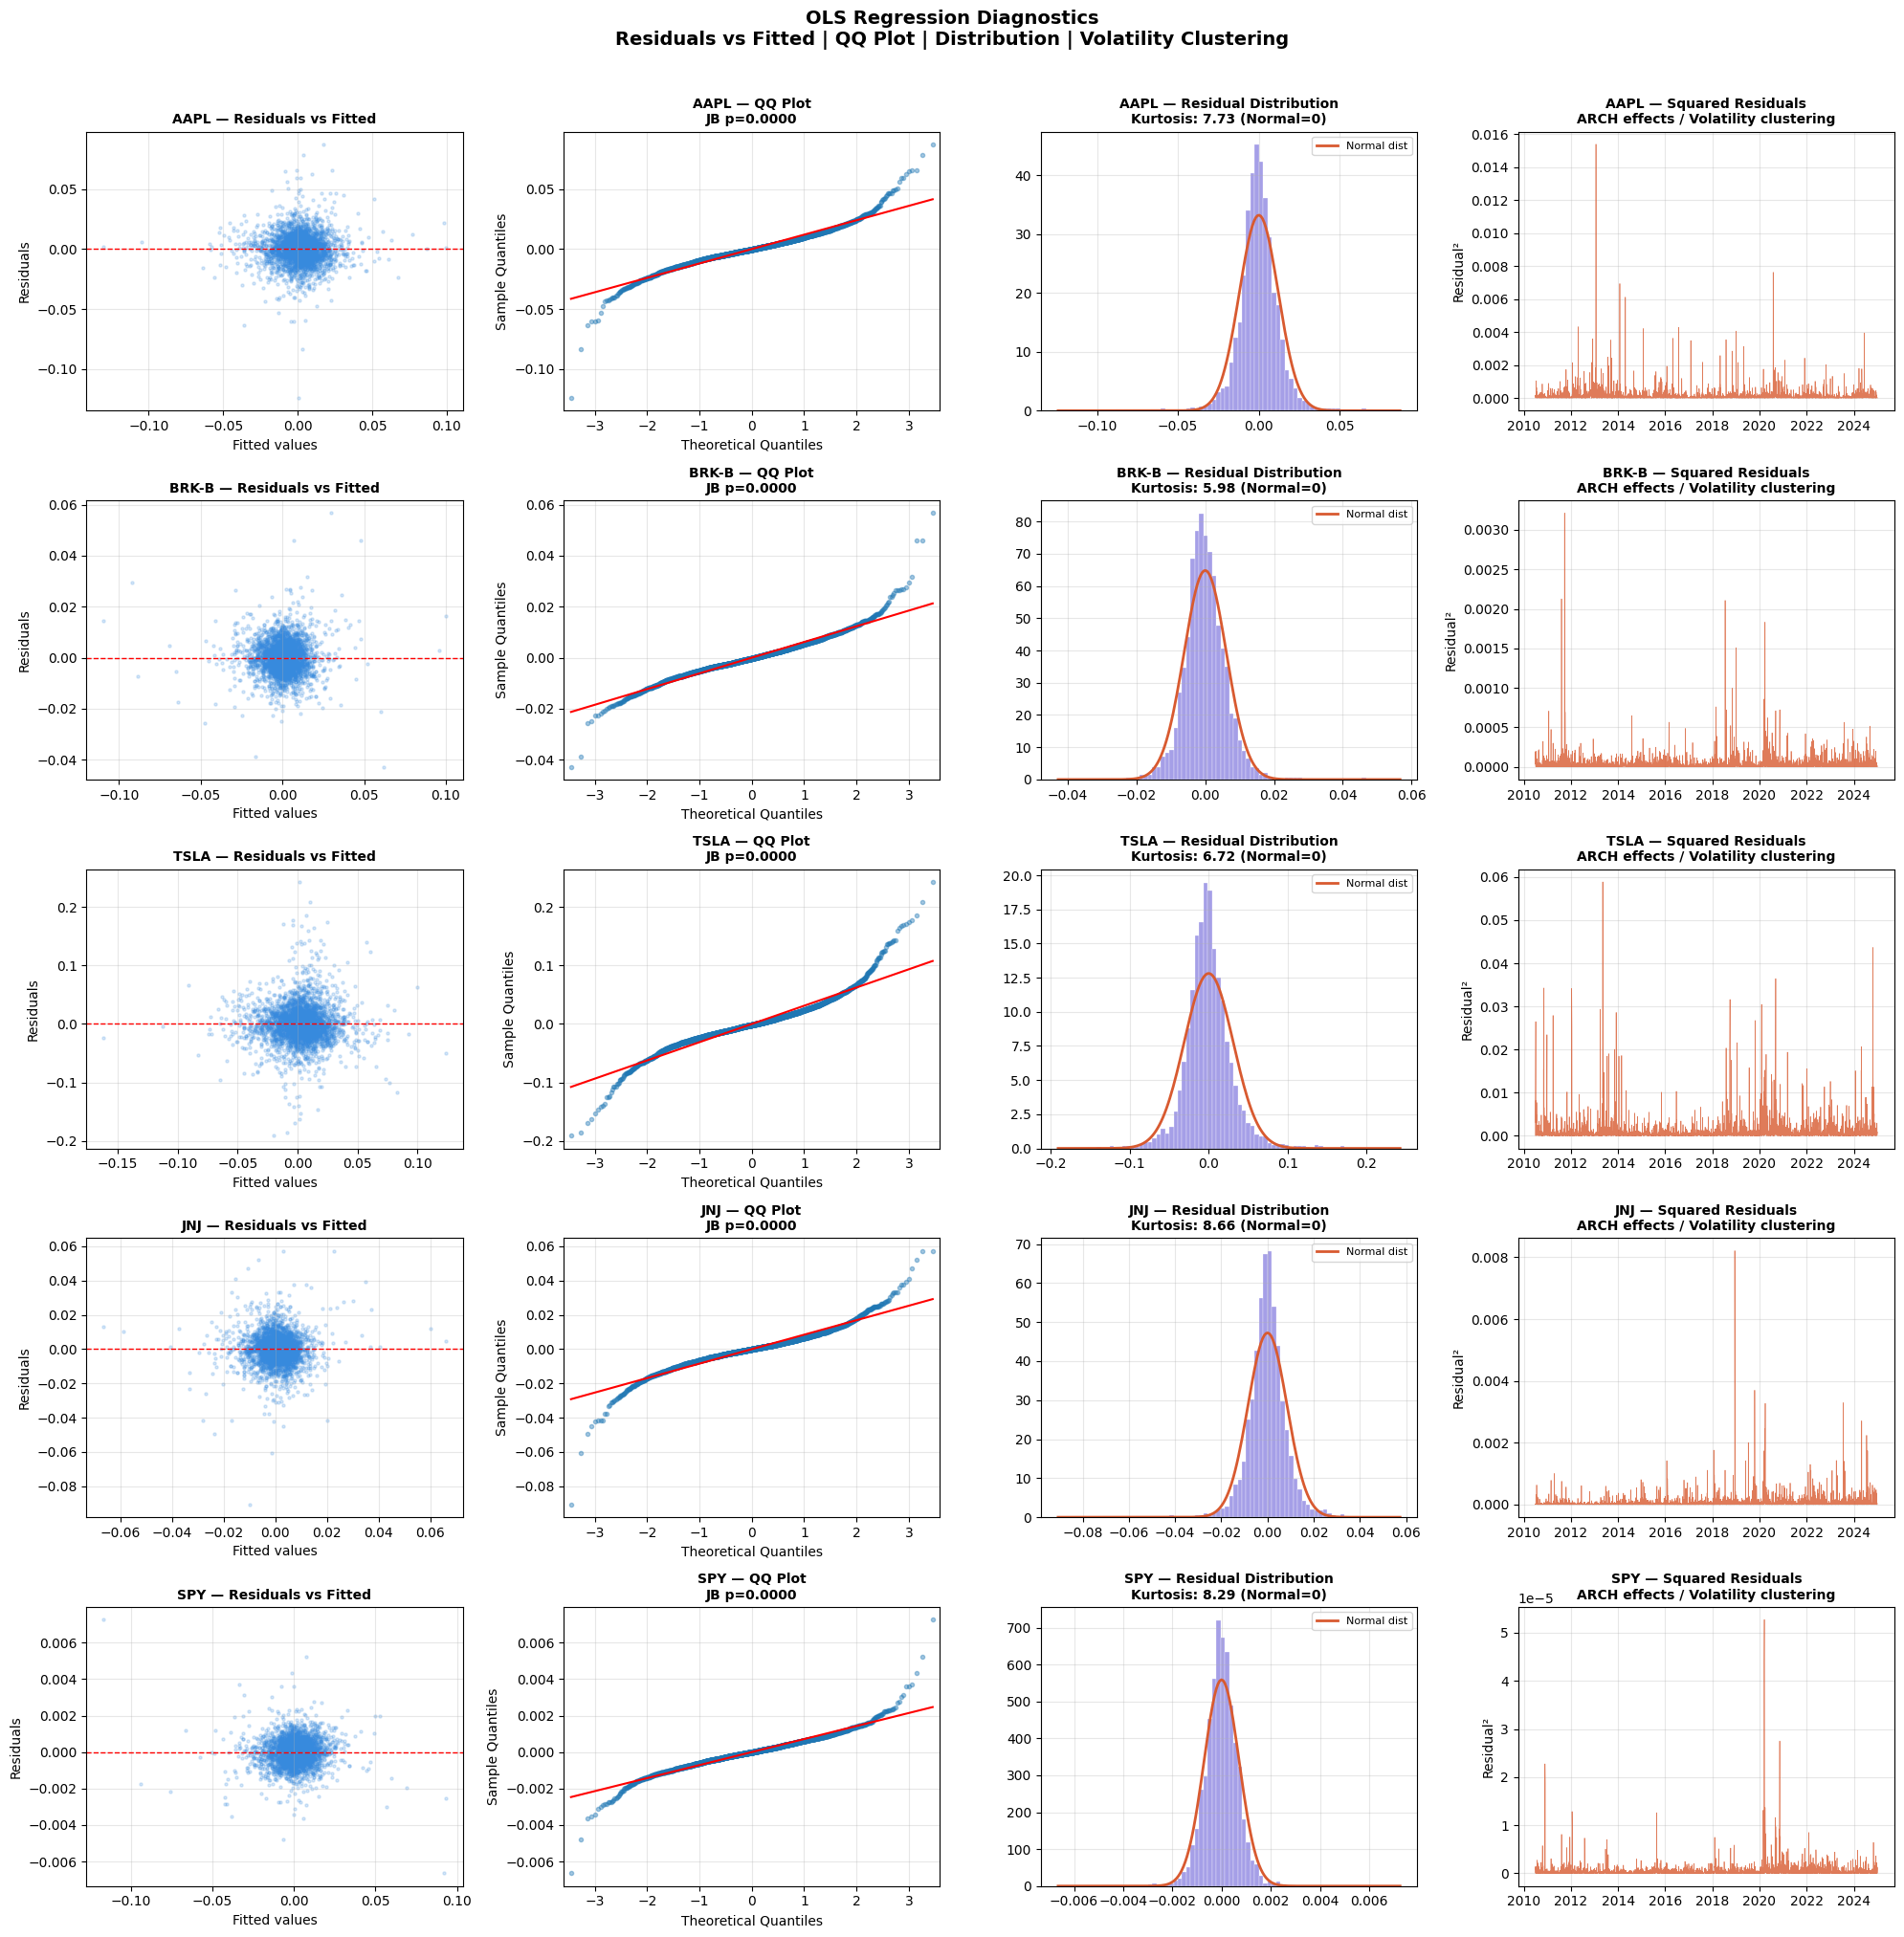

Diagnostic plots saved


In [8]:
# ============================================
# RESIDUAL DIAGNOSTIC PLOTS
# Professional model validation
# ============================================
fig, axes = plt.subplots(
    len(results), 4,
    figsize=(20, 4 * len(results))
)

if len(results) == 1:
    axes = axes.reshape(1, -1)

for row, (ticker, res) in enumerate(results.items()):
    resid  = res["resid"]
    fitted = res["fitted"]

    # Chart 1 — Residuals vs Fitted
    axes[row, 0].scatter(
        fitted, resid,
        alpha=0.2, color="#378ADD",
        s=5, rasterized=True
    )
    axes[row, 0].axhline(
        0, color="red",
        linewidth=1, linestyle="--")
    axes[row, 0].set_title(
        f"{ticker} — Residuals vs Fitted",
        fontweight="bold", fontsize=10)
    axes[row, 0].set_xlabel("Fitted values")
    axes[row, 0].set_ylabel("Residuals")
    axes[row, 0].grid(alpha=0.3)

    # Chart 2 — QQ plot (normality check)
    sm.qqplot(
        resid, line="s",
        ax=axes[row, 1],
        alpha=0.4,
        markersize=3
    )
    axes[row, 1].set_title(
        f"{ticker} — QQ Plot\n"
        f"JB p={res['jb_pval']:.4f}",
        fontweight="bold", fontsize=10)
    axes[row, 1].grid(alpha=0.3)

    # Chart 3 — Residual histogram
    axes[row, 2].hist(
        resid, bins=80,
        color="#7F77DD",
        alpha=0.7,
        density=True,
        edgecolor="white",
        linewidth=0.3
    )
    # Overlay normal distribution
    x_range = np.linspace(resid.min(), resid.max(), 200)
    normal_pdf = stats.norm.pdf(
        x_range, resid.mean(), resid.std())
    axes[row, 2].plot(
        x_range, normal_pdf,
        color="#D85A30", linewidth=2,
        label="Normal dist"
    )
    axes[row, 2].set_title(
        f"{ticker} — Residual Distribution\n"
        f"Kurtosis: {stats.kurtosis(resid):.2f} "
        f"(Normal=0)",
        fontweight="bold", fontsize=10)
    axes[row, 2].legend(fontsize=8)
    axes[row, 2].grid(alpha=0.3)

    # Chart 4 — Squared residuals (volatility clustering)
    axes[row, 3].plot(
        resid.index,
        resid**2,
        color="#D85A30",
        linewidth=0.5,
        alpha=0.8
    )
    axes[row, 3].set_title(
        f"{ticker} — Squared Residuals\n"
        f"ARCH effects / Volatility clustering",
        fontweight="bold", fontsize=10)
    axes[row, 3].set_ylabel("Residual²")
    axes[row, 3].grid(alpha=0.3)

plt.suptitle(
    "OLS Regression Diagnostics\n"
    "Residuals vs Fitted | QQ Plot | "
    "Distribution | Volatility Clustering",
    fontsize=14, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.savefig(
    "../reports/figures/ols_diagnostics.png",
    dpi=120, bbox_inches="tight"
)
plt.show()
print("Diagnostic plots saved")

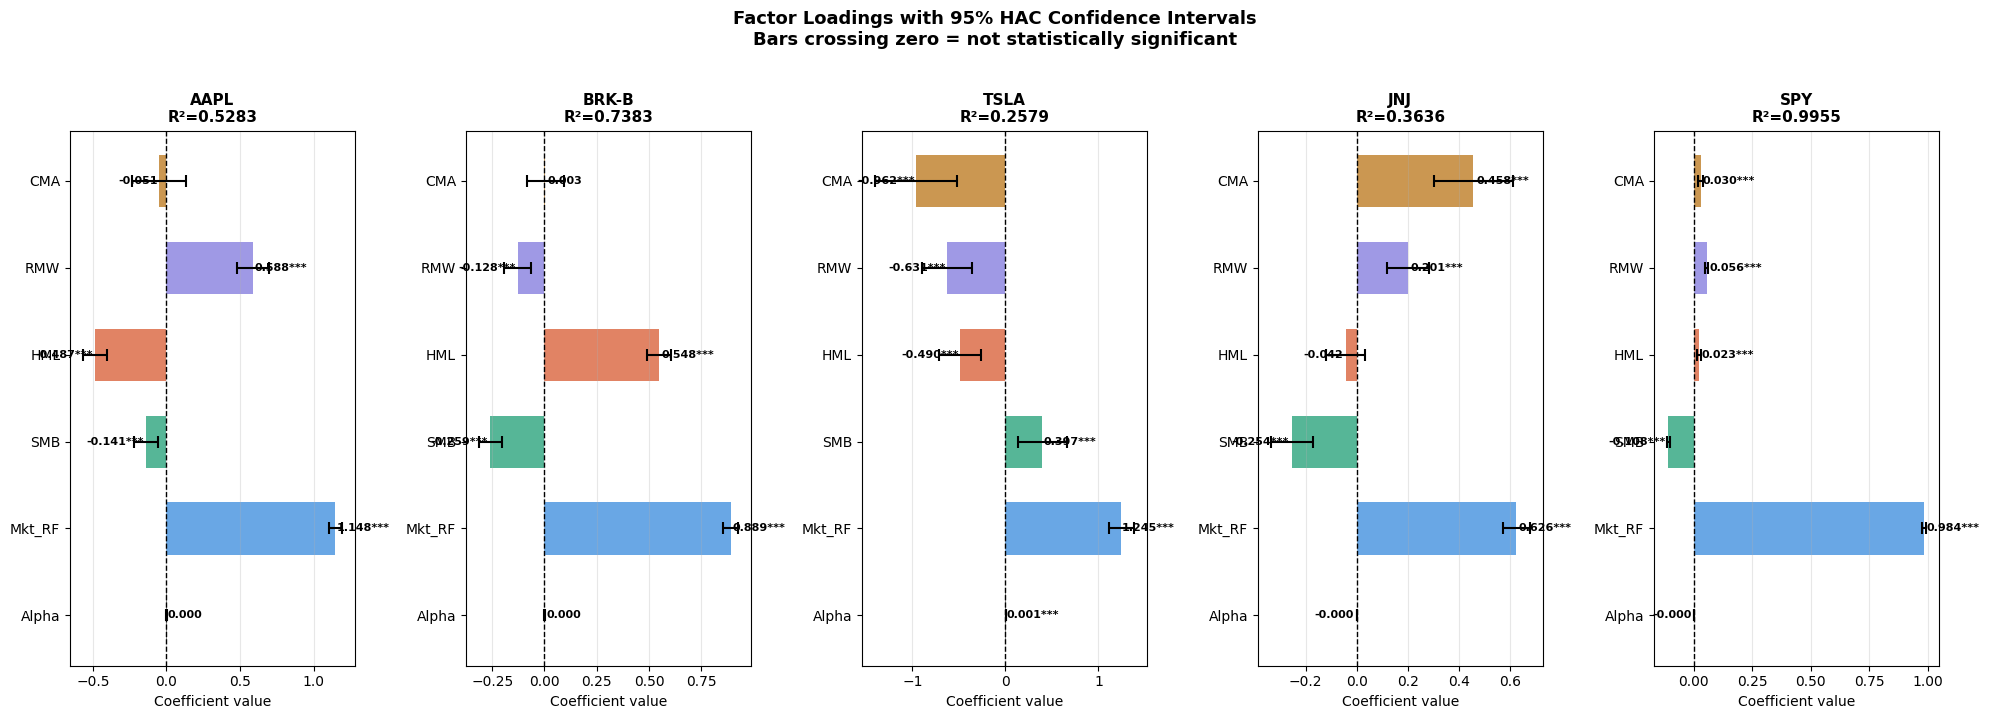

Confidence interval chart saved


In [9]:
# ============================================
# CONFIDENCE INTERVAL ANALYSIS
# Shows uncertainty around factor estimates
# ============================================
fig, axes = plt.subplots(
    1, len(results),
    figsize=(4 * len(results), 7)
)

if len(results) == 1:
    axes = [axes]

factor_colors = {
    "Alpha": "#444441",
    "Mkt_RF": "#378ADD",
    "SMB": "#1D9E75",
    "HML": "#D85A30",
    "RMW": "#7F77DD",
    "CMA": "#BA7517"
}

for ax, (ticker, res) in zip(axes, results.items()):
    params  = res["params"]
    ci      = res["conf_int"]

    param_names = params.index.tolist()
    values      = params.values
    lower       = ci.iloc[:, 0].values
    upper       = ci.iloc[:, 1].values
    y_pos       = np.arange(len(param_names))

    colors = [factor_colors.get(p, "grey")
              for p in param_names]

    ax.barh(
        y_pos, values,
        xerr=[values - lower, upper - values],
        color=colors, alpha=0.75,
        height=0.6, capsize=4,
        error_kw={"linewidth": 1.5,
                  "capthick": 1.5}
    )
    ax.axvline(
        0, color="black",
        linewidth=1, linestyle="--")
    ax.set_yticks(y_pos)
    ax.set_yticklabels(param_names, fontsize=10)
    ax.set_title(
        f"{ticker}\nR²={res['rsquared']:.4f}",
        fontweight="bold", fontsize=11
    )
    ax.set_xlabel("Coefficient value")
    ax.grid(alpha=0.3, axis="x")

    # Add values
    for y, val, p in zip(
            y_pos, values,
            res["pvalues"].values):
        sig = ("***" if p < 0.01 else
               "**"  if p < 0.05 else
               "*"   if p < 0.10 else "")
        ax.text(
            val + (0.01 if val >= 0 else -0.01),
            y,
            f"{val:.3f}{sig}",
            va="center",
            ha="left" if val >= 0 else "right",
            fontsize=8, fontweight="bold"
        )

plt.suptitle(
    "Factor Loadings with 95% HAC Confidence Intervals\n"
    "Bars crossing zero = not statistically significant",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.savefig(
    "../reports/figures/confidence_intervals.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Confidence interval chart saved")

In [10]:
# ============================================
# RETURN DECOMPOSITION
# Breaks each stock's total return into:
# Alpha + Factor contributions + Residual
# ============================================
print("=" * 65)
print("   RETURN DECOMPOSITION ANALYSIS")
print("   Total excess return = Alpha + Factors + Residual")
print("=" * 65)

decomp_rows = []
for ticker, res in results.items():
    model  = res["model"]
    params = res["params"]

    # Calculate factor contributions
    X = sm.add_constant(ff5[factors])
    X.columns = ["Alpha"] + factors
    y = excess[ticker].dropna()
    X = X.loc[y.index]

    # Annualised contributions
    alpha_contrib  = params["Alpha"] * 252
    factor_contribs= {
        f: params[f] * ff5[f].loc[y.index].mean() * 252
        for f in factors
    }
    total_factor   = sum(factor_contribs.values())
    residual       = (y.mean() * 252 -
                      alpha_contrib - total_factor)

    print(f"\n  {ticker}")
    print(f"  Total excess return (ann): "
          f"{y.mean()*252:.4f} ({y.mean()*252:.2%})")
    print(f"  ├─ Alpha contribution:     "
          f"{alpha_contrib:.4f} ({alpha_contrib:.2%})")
    for f, contrib in factor_contribs.items():
        print(f"  ├─ {f:<8} contribution: "
              f"{contrib:.4f} ({contrib:.2%})")
    print(f"  └─ Residual (unexplained): "
          f"{residual:.4f} ({residual:.2%})")
    print(f"  R-squared: {res['rsquared']:.4f} — "
          f"{res['rsquared']*100:.1f}% of return "
          f"variance explained by factors")

    decomp_rows.append({
        "Ticker":        ticker,
        "Total_Excess":  round(y.mean()*252, 4),
        "Alpha":         round(alpha_contrib, 4),
        "Mkt_Contrib":   round(factor_contribs["Mkt_RF"], 4),
        "SMB_Contrib":   round(factor_contribs["SMB"], 4),
        "HML_Contrib":   round(factor_contribs["HML"], 4),
        "RMW_Contrib":   round(factor_contribs["RMW"], 4),
        "CMA_Contrib":   round(factor_contribs["CMA"], 4),
        "Residual":      round(residual, 4),
    })

decomp_df = pd.DataFrame(
    decomp_rows).set_index("Ticker")
decomp_df.to_csv(
    "../data/processed/return_decomposition.csv")
print("\n" + "=" * 65)
print("Saved to data/processed/return_decomposition.csv")

   RETURN DECOMPOSITION ANALYSIS
   Total excess return = Alpha + Factors + Residual

  AAPL
  Total excess return (ann): 0.2676 (26.76%)
  ├─ Alpha contribution:     0.0747 (7.47%)
  ├─ Mkt_RF   contribution: 0.1628 (16.28%)
  ├─ SMB      contribution: 0.0017 (0.17%)
  ├─ HML      contribution: 0.0098 (0.98%)
  ├─ RMW      contribution: 0.0185 (1.85%)
  ├─ CMA      contribution: 0.0000 (0.00%)
  └─ Residual (unexplained): -0.0000 (-0.00%)
  R-squared: 0.5283 — 52.8% of return variance explained by factors

  BRK-B
  Total excess return (ann): 0.1261 (12.61%)
  ├─ Alpha contribution:     0.0119 (1.19%)
  ├─ Mkt_RF   contribution: 0.1260 (12.60%)
  ├─ SMB      contribution: 0.0032 (0.32%)
  ├─ HML      contribution: -0.0110 (-1.10%)
  ├─ RMW      contribution: -0.0040 (-0.40%)
  ├─ CMA      contribution: -0.0000 (-0.00%)
  └─ Residual (unexplained): -0.0000 (-0.00%)
  R-squared: 0.7383 — 73.8% of return variance explained by factors

  TSLA
  Total excess return (ann): 0.5366 (53.66%)
 

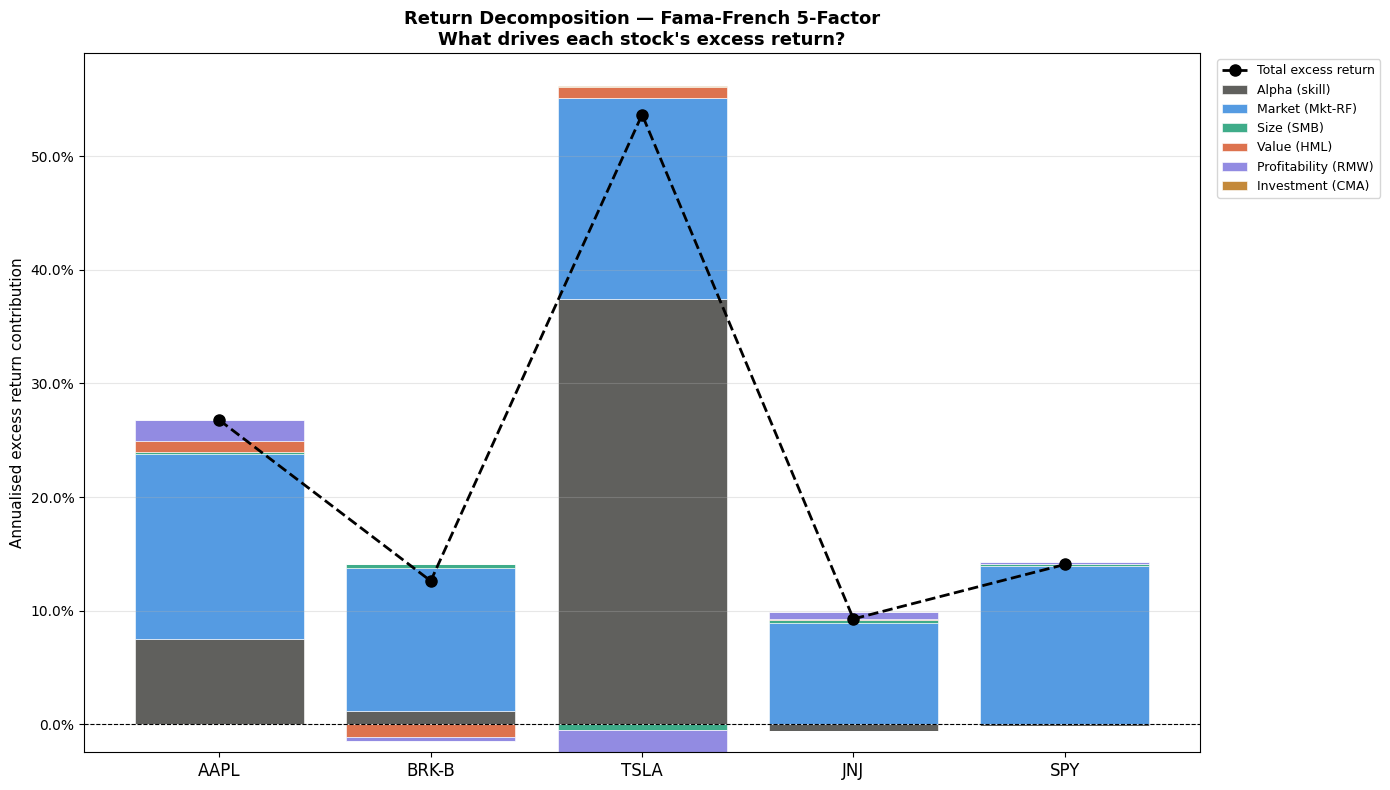

Return decomposition chart saved


In [11]:
# ============================================
# RETURN DECOMPOSITION STACKED BAR CHART
# ============================================
fig, ax = plt.subplots(figsize=(14, 8))

components = [
    "Alpha", "Mkt_Contrib", "SMB_Contrib",
    "HML_Contrib", "RMW_Contrib", "CMA_Contrib"
]
comp_labels = [
    "Alpha (skill)", "Market (Mkt-RF)",
    "Size (SMB)", "Value (HML)",
    "Profitability (RMW)", "Investment (CMA)"
]
comp_colors = [
    "#444441", "#378ADD", "#1D9E75",
    "#D85A30", "#7F77DD", "#BA7517"
]

x_pos    = np.arange(len(decomp_df))
bottoms  = np.zeros(len(decomp_df))
neg_btms = np.zeros(len(decomp_df))

for comp, label, color in zip(
        components, comp_labels, comp_colors):
    values = decomp_df[comp].values

    pos_vals = np.where(values > 0, values, 0)
    neg_vals = np.where(values < 0, values, 0)

    ax.bar(x_pos, pos_vals, bottom=bottoms,
           color=color, label=label,
           alpha=0.85, edgecolor="white",
           linewidth=0.5)
    ax.bar(x_pos, neg_vals, bottom=neg_btms,
           color=color, alpha=0.85,
           edgecolor="white", linewidth=0.5)

    bottoms  += pos_vals
    neg_btms += neg_vals

# Total return line
ax.plot(x_pos, decomp_df["Total_Excess"].values,
        "ko--", linewidth=2,
        markersize=8, label="Total excess return",
        zorder=5)

ax.axhline(0, color="black",
           linewidth=0.8, linestyle="--")
ax.set_xticks(x_pos)
ax.set_xticklabels(
    decomp_df.index, fontsize=12)
ax.set_ylabel(
    "Annualised excess return contribution",
    fontsize=11)
ax.set_title(
    "Return Decomposition — Fama-French 5-Factor\n"
    "What drives each stock's excess return?",
    fontweight="bold", fontsize=13
)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.1%}"))
ax.legend(
    loc="upper left",
    fontsize=9,
    bbox_to_anchor=(1.01, 1)
)
ax.grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(
    "../reports/figures/return_decomposition.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Return decomposition chart saved")

In [12]:
# ============================================
# SPY VALIDATION — THE SANITY CHECK
# SPY beta should be ~1.0, alpha ~0
# If not, something is wrong with the data
# ============================================
spy_res = results.get("SPY")

print("=" * 60)
print("   SPY VALIDATION CHECK")
print("   Expected: Beta ≈ 1.0 | Alpha ≈ 0")
print("=" * 60)

if spy_res:
    beta  = spy_res["params"]["Mkt_RF"]
    alpha = spy_res["alpha_ann"]
    r2    = spy_res["rsquared"]
    print(f"\n  Market Beta:  {beta:.4f} "
          f"(expected ~1.0)")
    print(f"  Annualised α: {alpha:.4f} "
          f"(expected ~0.0)")
    print(f"  R-squared:    {r2:.4f} "
          f"(expected ~0.99)")
    print(f"\n  Beta deviation from 1.0: "
          f"{abs(beta - 1.0):.4f}")

    if abs(beta - 1.0) < 0.05 and abs(alpha) < 0.01:
        print(f"  VALIDATION PASSED ✓")
        print(f"  Data alignment confirmed correct")
    else:
        print(f"  WARNING: Check data alignment")

print("\n" + "=" * 60)
print("   NB2 COMPLETE")
print("=" * 60)
print(f"  Models fitted:    {len(results)}")
print(f"  Charts saved:     4")
print(f"  Files saved:      2")
print(f"  Standard errors:  HAC (Newey-West)")
print(f"  Diagnostic tests: BP, LB, JB")
print("=" * 60)
print("\nMove to 03_rolling_regression.ipynb")

   SPY VALIDATION CHECK
   Expected: Beta ≈ 1.0 | Alpha ≈ 0

  Market Beta:  0.9835 (expected ~1.0)
  Annualised α: -0.0014 (expected ~0.0)
  R-squared:    0.9955 (expected ~0.99)

  Beta deviation from 1.0: 0.0165
  VALIDATION PASSED ✓
  Data alignment confirmed correct

   NB2 COMPLETE
  Models fitted:    5
  Charts saved:     4
  Files saved:      2
  Standard errors:  HAC (Newey-West)
  Diagnostic tests: BP, LB, JB

Move to 03_rolling_regression.ipynb
